In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


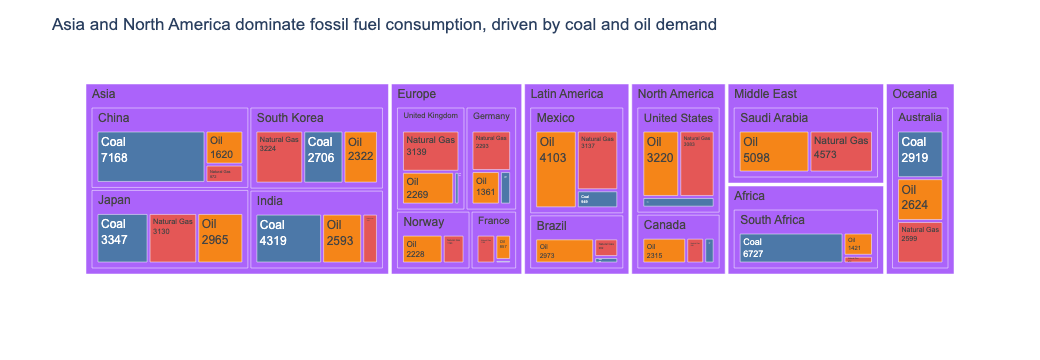

In [2]:
fossil = df[df['Source_Type'] == 'Fossil']

fig = px.treemap(
    fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4C78A8',
        'Oil': '#F58518',
        'Natural Gas': '#E45756'
    }
)

fig.update_traces(
    textinfo='label+value',
    marker=dict(line=dict(width=0.5, color='white'))
)

fig.update_layout(
    title="Asia and North America dominate fossil fuel consumption, driven by coal and oil demand",
    template="plotly_white",
    font=dict(family="Arial")
)

fig.show()

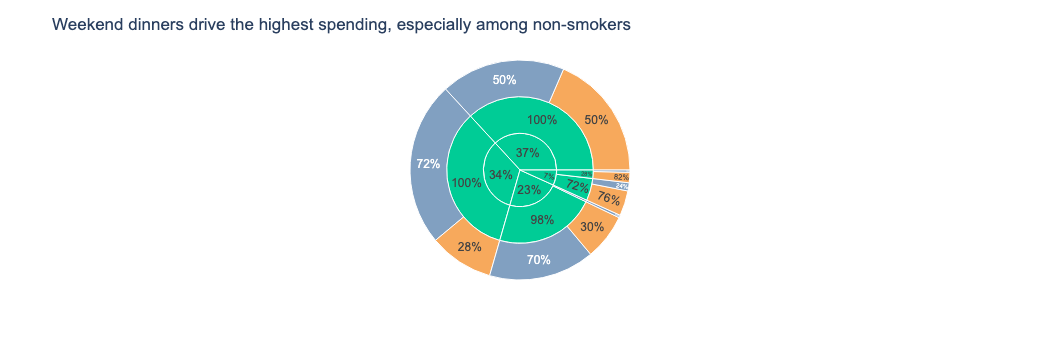

In [3]:
tips = px.data.tips()

tips_grouped = tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()

fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#F58518',
        'No': '#4C78A8'
    }
)

fig.update_traces(
    textinfo='percent parent',
    marker=dict(line=dict(color='white', width=1))
)

fig.update_layout(
    title="Weekend dinners drive the highest spending, especially among non-smokers",
    template="plotly_white",
    font=dict(family="Arial")
)

fig.show()

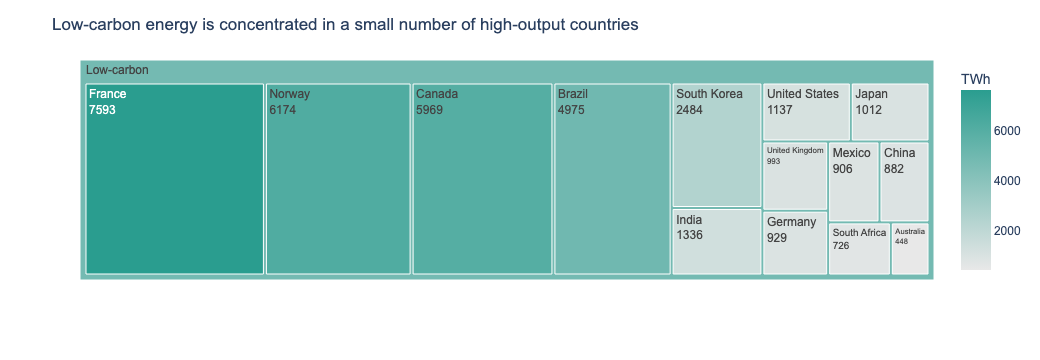

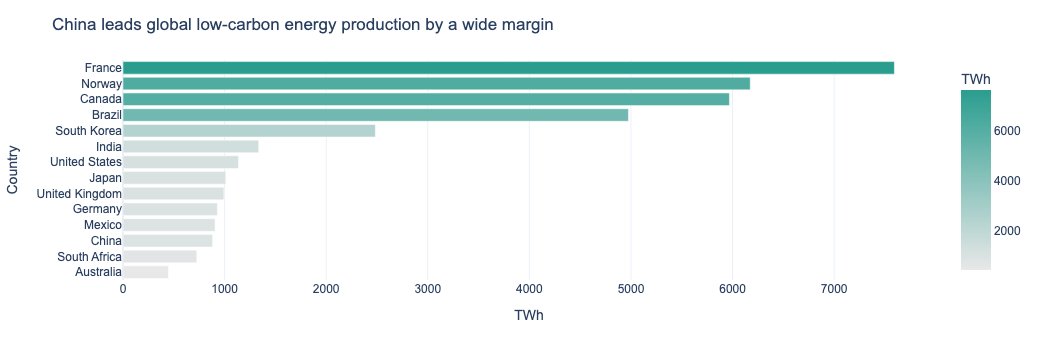

In [4]:
low_carbon = df[df['Source_Type'] == 'Low-carbon']
country_energy = low_carbon.groupby('Country')['TWh'].sum().reset_index()
country_energy = country_energy.sort_values('TWh', ascending=False)
treemap_df = country_energy.copy()
treemap_df['All'] = 'Low-carbon'

fig1 = px.treemap(
    treemap_df,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale=['#E8E8E8', '#2A9D8F']
)

fig1.update_traces(
    textinfo='label+value'
)

fig1.update_layout(
    title="Low-carbon energy is concentrated in a small number of high-output countries",
    template="plotly_white",
    font=dict(family="Arial")
)

fig1.show()
fig2 = px.bar(
    country_energy,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale=['#E8E8E8', '#2A9D8F']
)

fig2.update_layout(
    title="China leads global low-carbon energy production by a wide margin",
    template="plotly_white",
    font=dict(family="Arial"),
    yaxis=dict(categoryorder='total ascending')
)

fig2.show()